In [1]:
%pip install networkx[default]

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)

   ---------------------------------------- 0/2 [contourpy]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 [matplotlib]
   -------------------- ------------------- 1/2 

{'current': 'F', 'visited': {'F', 'B', 'D', 'C', 'E', 'A'}, 'dist': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 5, 'F': 5}}


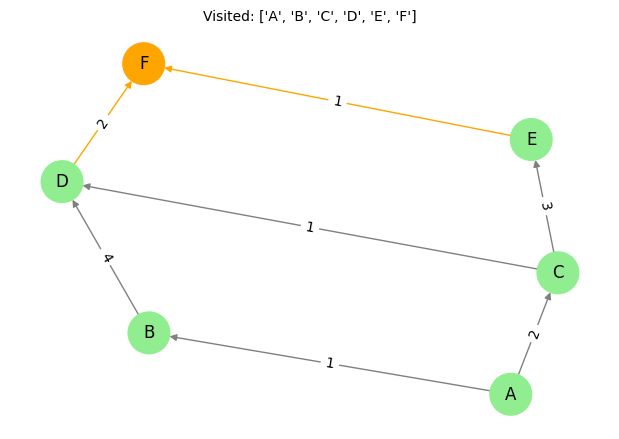

In [2]:
%matplotlib inline

import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time


def draw_graph(G, pos, visited=None, current=None, queue=None, dist=None):
    visited = visited or set()
    node_colors = []
    for node in G.nodes():
        if node == current:
            node_colors.append('orange')
        elif node in visited:
            node_colors.append('lightgreen')
        else:
            node_colors.append('lightgray')

    edge_colors = []
    for u, v in G.edges():
        if current is not None and (u == current or v == current):
            edge_colors.append('orange')
        else:
            edge_colors.append('gray')

    plt.figure(figsize=(6, 4))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color=edge_colors, node_size=900, font_size=12)

    if dist is not None:
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    title_lines = []
    if queue is not None:
        title_lines.append(f"Queue: {queue}")
    if visited:
        title_lines.append(f"Visited: {sorted(visited)}")
    plt.title('\n'.join(title_lines), fontsize=10)
    plt.axis('off')
    display(plt.gcf())
    plt.close()


def bfs_steps(G, start):
    visited = set()
    queue = [start]
    steps = []

    while queue:
        current = queue.pop(0)
        if current in visited:
            continue
        visited.add(current)
        steps.append({'current': current, 'visited': set(visited), 'queue': list(queue)})

        for neighbor in sorted(G.neighbors(current)):
            if neighbor not in visited and neighbor not in queue:
                queue.append(neighbor)

    return steps


def dfs_steps(G, start):
    visited = set()
    stack = [start]
    steps = []

    while stack:
        current = stack.pop()
        if current in visited:
            continue
        visited.add(current)
        steps.append({'current': current, 'visited': set(visited), 'stack': list(stack)})

        for neighbor in sorted(G.neighbors(current), reverse=True):
            if neighbor not in visited:
                stack.append(neighbor)

    return steps


def dijkstra_steps(G, start):
    dist = {node: float('inf') for node in G.nodes()}
    dist[start] = 0
    visited = set()
    steps = []

    while len(visited) < len(G.nodes()):
        unvisited_nodes = {node: dist[node] for node in G.nodes() if node not in visited}
        if not unvisited_nodes:
            break

        current = min(unvisited_nodes, key=unvisited_nodes.get)
        visited.add(current)
        steps.append({'current': current, 'visited': set(visited), 'dist': dict(dist)})

        for neighbor in G.neighbors(current):
            new_dist = dist[current] + G[current][neighbor].get('weight', 1)
            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist

    return steps


# Build a small graph to explore
G = nx.DiGraph()
G.add_weighted_edges_from([
    ('A', 'B', 1),
    ('A', 'C', 2),
    ('B', 'D', 4),
    ('C', 'D', 1),
    ('C', 'E', 3),
    ('D', 'F', 2),
    ('E', 'F', 1),
])

pos = nx.spring_layout(G, seed=42)

print('Graph nodes:', G.nodes())
print('Graph edges with weights:', list(G.edges(data='weight')))

# Visualize the base graph
plt.figure(figsize=(6, 4))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=900, font_size=12)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.axis('off')
plt.show()

print('\nBFS steps:')
for step in bfs_steps(G, 'A'):
    clear_output(wait=True)
    print(step)
    draw_graph(G, pos, visited=step['visited'], current=step['current'], queue=step['queue'])
    time.sleep(0.7)

print('\nDFS steps:')
for step in dfs_steps(G, 'A'):
    clear_output(wait=True)
    print(step)
    draw_graph(G, pos, visited=step['visited'], current=step['current'], queue=step['stack'])
    time.sleep(0.7)

print('\nDijkstra steps:')
for step in dijkstra_steps(G, 'A'):
    clear_output(wait=True)
    print(step)
    draw_graph(G, pos, visited=step['visited'], current=step['current'], dist=step['dist'])
    time.sleep(0.7)